In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
num_sample=1000
sample_size=30
distribution_range=(0,1)
samples=np.random.uniform(distribution_range[0],distribution_range[1],(num_sample,sample_size))
sample_mean=samples.mean(axis=1)
print(sample_mean)


[0.47661815 0.50883181 0.56823211 0.50591541 0.49936415 0.4522092
 0.37722342 0.51919661 0.48530641 0.46760206 0.46896902 0.46948428
 0.5232742  0.47795745 0.57221012 0.49460286 0.49267535 0.47861339
 0.56340442 0.48270621 0.55064048 0.47698215 0.4725316  0.59727837
 0.47786491 0.48144287 0.48054521 0.5299433  0.4641859  0.52968956
 0.53125238 0.56131964 0.36193027 0.43600006 0.53068148 0.51831902
 0.52690397 0.46476487 0.59232527 0.44903188 0.5719759  0.52748231
 0.43998676 0.52926873 0.57856688 0.52701237 0.59094231 0.47722282
 0.63441273 0.53376614 0.51192533 0.49701679 0.52809151 0.4517516
 0.54591306 0.5228417  0.50094811 0.42094036 0.47138129 0.5029172
 0.48323447 0.55137913 0.52639059 0.53708921 0.55510598 0.47201316
 0.46041075 0.44225097 0.46354088 0.42897219 0.49267469 0.58184963
 0.49528818 0.52508808 0.46890772 0.46580879 0.45943039 0.45365159
 0.54941224 0.47601794 0.46805085 0.56977069 0.4770428  0.57405951
 0.43681671 0.54464134 0.534905   0.47133304 0.49293605 0.5470623

<Axes: ylabel='Count'>

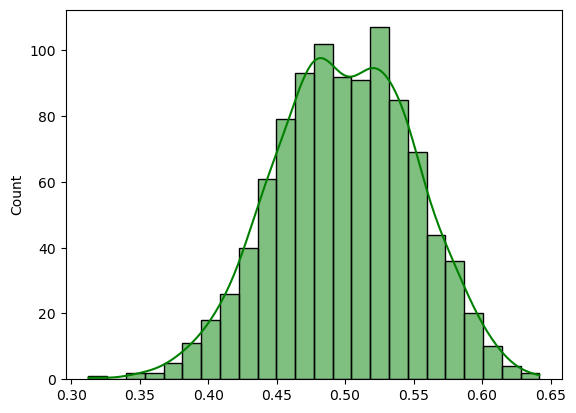

In [ ]:
# we created 1000 samples of size 30 and took the mean of each sample and stored it in sample_mean and then plotted the histogram got normal distribution
sns.histplot(data=sample_mean,color='green',kde=True)

In [ ]:
# we are going to infer the population mean and population standard deviation from the sample mean and sample standard deviation
pd.read_csv('train.csv').shape# train has 891 rows and 12 columns



(891, 12)

In [22]:
pd.read_csv('test.csv').shape # test has 418 rows and 11 columns

(418, 11)

In [27]:
df=pd.concat([pd.read_csv('train.csv').drop(columns=['Survived']),pd.read_csv('test.csv')])

In [28]:
df.shape

(1309, 11)

In [29]:
df=df.sample(1309)

In [33]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<Axes: ylabel='Density'>

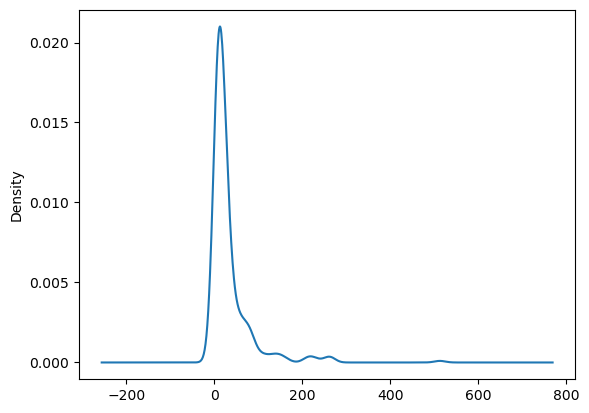

In [34]:
df['Fare'].plot(kind='kde')

In [36]:
type(df['Fare'].sample(5))

pandas.core.series.Series

In [47]:
sample=[]
for i in range(100):
    trial=df['Fare'].dropna().sample(50).tolist()
    sample.append(trial)

sample=np.array(sample)
sample

array([[  7.75  ,  13.    , 106.425 , ...,  21.    ,   7.775 ,   7.775 ],
       [  7.4958,   7.8958,   7.8958, ...,   7.4958,  30.0708,   7.925 ],
       [ 14.4583,  27.9   ,  27.7208, ...,   8.05  ,  42.5   ,  26.    ],
       ...,
       [ 26.    ,  10.5   ,  51.8625, ...,   7.7333,  41.5792,  32.5   ],
       [ 14.5   ,  26.    ,  31.275 , ...,   7.925 ,   8.05  ,   7.8542],
       [ 13.    ,  16.1   ,   3.1708, ...,   7.05  ,   7.8542,   8.3625]],
      shape=(100, 50))

In [48]:
sample_mean=sample.mean(axis=1)

In [49]:
sample_mean.shape

(100,)

<Axes: ylabel='Count'>

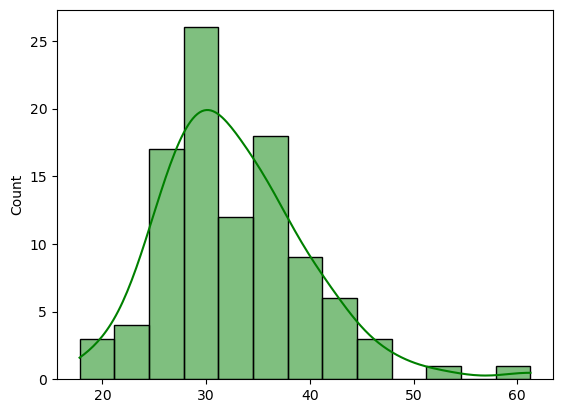

In [50]:
sns.histplot(data=sample_mean,color='green',kde=True)

In [52]:
sample_mean.mean()

np.float64(32.7194389)

In [ ]:
sample_mean.std()# sample standard deviation

np.float64(7.005016146149497)

In [54]:
#population standar daviation will be sample std / sqrt(n)
sample_mean.std()/np.sqrt(50)

np.float64(0.990658883852713)

In [62]:
# we are taking 2 standard daviations from mean as normal distribution emperical rule states that 99.7% of the population lies within 2 standard daviations from the mean ao we can say we are 95% confident that the population mean is between lowerlimit and upperlimit
lowerlimit=sample_mean.mean()-2*sample_mean.std()/np.sqrt(50)
print(lowerlimit)

upperlimit=sample_mean.mean()+2*sample_mean.std()/np.sqrt(50)
print(upperlimit)

print("Range is ",lowerlimit,'-',upperlimit)

30.738121132294573
34.70075666770543
Range is  30.738121132294573 - 34.70075666770543


In [61]:
# now check orginal population mean and population standard deviation
print(df['Fare'].mean())# population mean 


33.29547928134557
